## Đọc dữ liệu





In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

Read data file


In [25]:
train_df = pd.read_csv("/content/drive/MyDrive/CCNLTHD/train.csv")
val_df = pd.read_csv("/content/drive/MyDrive/CCNLTHD/validation.csv")
test_df = pd.read_csv("/content/drive/MyDrive/CCNLTHD/test.csv")

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (11426, 5)
Validation shape: (1583, 5)
Test shape: (3166, 5)


Đặt tên và gộp file

In [26]:
train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print("Tổng số dòng:", df.shape[0])
print("Tổng số cột:", df.shape[1])
df.head()

Tổng số dòng: 16175
Tổng số cột: 6


,sentence,sentiment,topic,sentiment_label,topic_label,split
0,slide giáo trình đầy đủ .,2,1,positive,training_program,train
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,positive,lecturer,train
2,đi học đầy đủ full điểm chuyên cần .,0,1,negative,training_program,train
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,negative,lecturer,train
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,positive,lecturer,train


Xem tổng quan

In [23]:
print("TRAIN")
display(train_df.head())

print("VALIDATION")
display(val_df.head())

print("TEST")
display(test_df.head())

TRAIN


,sentence,sentiment,topic,sentiment_label,topic_label,split
0,slide giáo trình đầy đủ .,2,1,positive,training_program,train
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,positive,lecturer,train
2,đi học đầy đủ full điểm chuyên cần .,0,1,negative,training_program,train
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,negative,lecturer,train
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,positive,lecturer,train


VALIDATION


,sentence,sentiment,topic,sentiment_label,topic_label,split
0,giáo trình chưa cụ thể .,0,1,negative,training_program,validation
1,giảng buồn ngủ .,0,0,negative,lecturer,validation
2,"giáo viên vui tính , tận tâm .",2,0,positive,lecturer,validation
3,"giảng viên nên giao bài tập nhiều hơn , chia n...",0,0,negative,lecturer,validation
4,"giảng viên cần giảng bài chi tiết hơn , đi sâu...",0,0,negative,lecturer,validation


TEST


,sentence,sentiment,topic,sentiment_label,topic_label,split
0,nói tiếng anh lưu loát .,2,0,positive,lecturer,test
1,giáo viên rất vui tính .,2,0,positive,lecturer,test
2,cô max có tâm .,2,0,positive,lecturer,test
3,"giảng bài thu hút , dí dỏm .",2,0,positive,lecturer,test
4,"giáo viên không giảng dạy kiến thức , hướng dẫ...",0,0,negative,lecturer,test


Kiểm tra dữ liệu thiếu, trùng lặp


In [5]:
print("===== GIÁ TRỊ THIẾU =====")
print(df.isnull().sum())

print("\n===== DÒNG BỊ TRÙNG =====")
print("Số dòng trùng hoàn toàn:", df.duplicated().sum())

print("\n===== CÂU BỊ TRÙNG =====")
print("Số câu bị trùng:", df["sentence"].duplicated().sum())

===== GIÁ TRỊ THIẾU =====
sentence           0
sentiment          0
topic              0
sentiment_label    0
topic_label        0
split              0
dtype: int64

===== DÒNG BỊ TRÙNG =====
Số dòng trùng hoàn toàn: 0

===== CÂU BỊ TRÙNG =====
Số câu bị trùng: 1


##Xử lý data

In [6]:
df.drop_duplicates(subset=['sentence'], inplace=True)

print("Số câu bị trùng sau khi xử lý:", df["sentence"].duplicated().sum())
print("Tổng số dòng sau khi xử lý trùng lặp:", df.shape[0])

Số câu bị trùng sau khi xử lý: 0
Tổng số dòng sau khi xử lý trùng lặp: 16174


Kiểm tra phân bố theo từng tập

In [27]:
df["split"].value_counts()

,count
split,
train,11426
test,3166
validation,1583


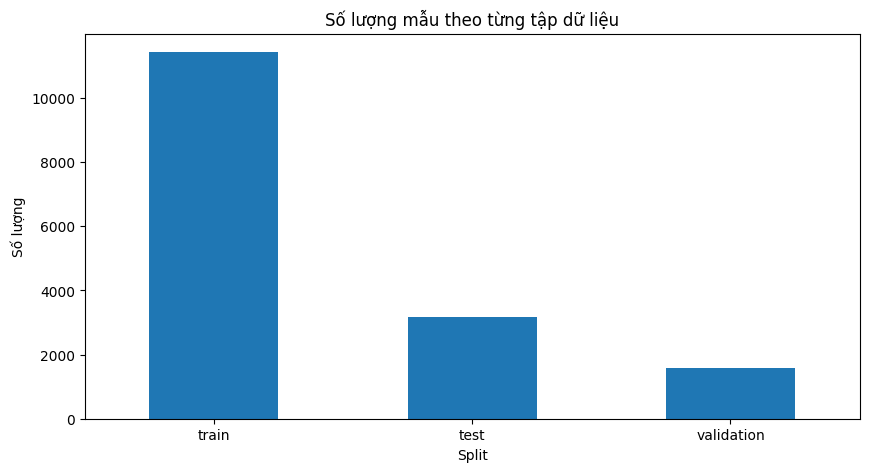

In [31]:
df["split"].value_counts().plot(kind="bar")
plt.title("Số lượng mẫu theo từng tập dữ liệu")
plt.xlabel("Split")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.show()

Phân bố sentiment

In [29]:
df["sentiment_label"].value_counts()

,count
sentiment_label,
positive,8038
negative,7439
neutral,698


Phân bố sentiment theo từng split

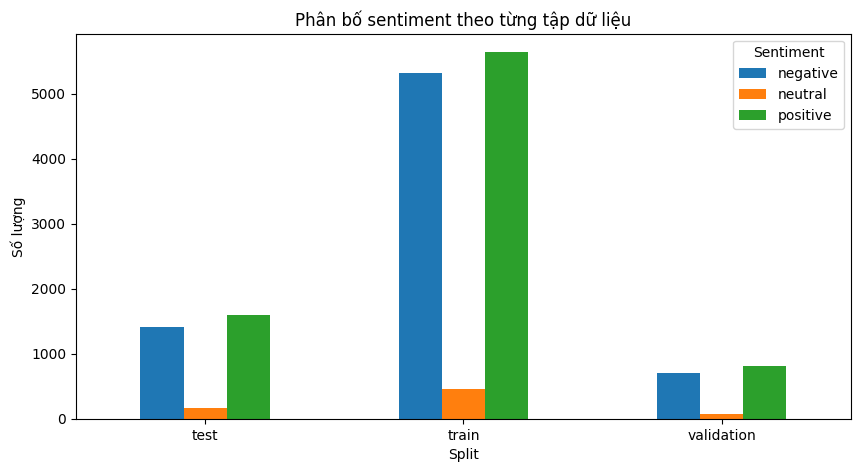

In [34]:

sentiment_by_split.plot(kind="bar")
plt.title("Phân bố sentiment theo từng tập dữ liệu")
plt.xlabel("Split")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.legend(title="Sentiment")
plt.show()

Phân bố topic

===== PHÂN BỐ TOPIC TOÀN BỘ DỮ LIỆU =====


,count
topic_label,
lecturer,11607
training_program,3040
others,816
facility,712


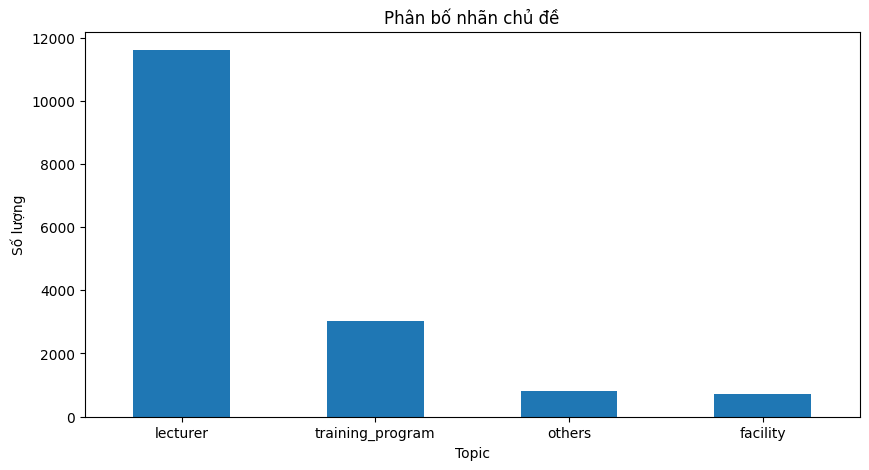

In [35]:
print("===== PHÂN BỐ TOPIC TOÀN BỘ DỮ LIỆU =====")
display(df["topic_label"].value_counts())

df["topic_label"].value_counts().plot(kind="bar")
plt.title("Phân bố nhãn chủ đề")
plt.xlabel("Topic")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.show()

Phân bố topic theo từng split

topic_label,facility,lecturer,others,training_program
split,,,,
test,145,2290,159,572
train,497,8166,562,2201
validation,70,1151,95,267


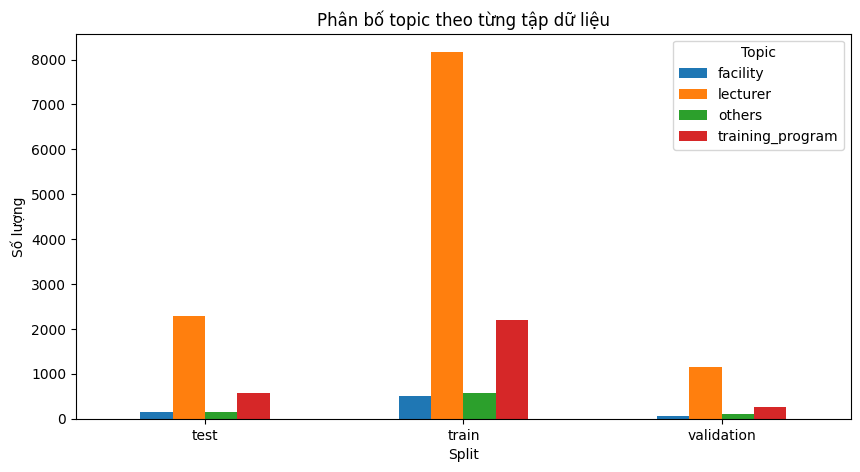

In [36]:
topic_by_split = pd.crosstab(df["split"], df["topic_label"])
display(topic_by_split)

topic_by_split.plot(kind="bar")
plt.title("Phân bố topic theo từng tập dữ liệu")
plt.xlabel("Split")
plt.ylabel("Số lượng")
plt.xticks(rotation=0)
plt.legend(title="Topic")
plt.show()

## Đặc trưng độ dài câu

In [37]:
df["char_count"] = df["sentence"].astype(str).apply(len)
df["word_count"] = df["sentence"].astype(str).apply(lambda x: len(x.split()))
display(df[["sentence", "char_count", "word_count"]].head())

,sentence,char_count,word_count
0,slide giáo trình đầy đủ .,25,6
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",46,11
2,đi học đầy đủ full điểm chuyên cần .,36,9
3,chưa áp dụng công nghệ thông tin và các thiết ...,76,18
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",59,15


## Thống kê độ dài câu

In [38]:
df[["char_count", "word_count"]].describe()

,char_count,word_count
count,16175.000000,16175.000000
mean,58.769768,14.229181
std,43.264994,10.103769
min,4.000000,2.000000
25%,31.000000,8.000000
50%,46.000000,11.000000
75%,73.000000,17.000000
max,718.000000,161.000000


Vẽ histogram số từ

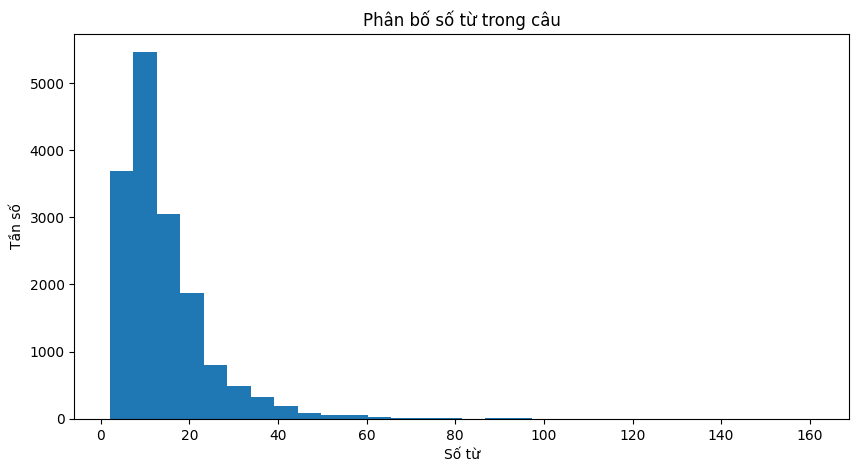

In [39]:
plt.hist(df["word_count"], bins=30)
plt.title("Phân bố số từ trong câu")
plt.xlabel("Số từ")
plt.ylabel("Tần số")
plt.show()

Vẽ histogram số ký tự

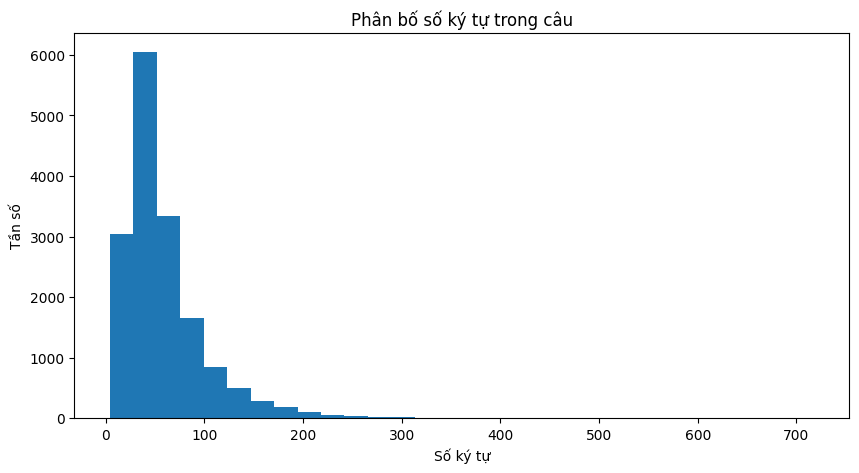

In [40]:
plt.hist(df["char_count"], bins=30)
plt.title("Phân bố số ký tự trong câu")
plt.xlabel("Số ký tự")
plt.ylabel("Tần số")
plt.show()

Độ dài câu trung bình của sentiment




In [41]:
df.groupby("sentiment_label")[["word_count", "char_count"]].mean().round(2)

,word_count,char_count
sentiment_label,,
negative,16.89,70.54
neutral,9.82,39.19
positive,12.15,49.57


Độ dài câu trung bình của topic




In [42]:
df.groupby("topic_label")[["word_count", "char_count"]].mean().round(2)

,word_count,char_count
topic_label,,
facility,16.97,71.35
lecturer,13.70,56.56
others,9.95,39.22
training_program,16.76,69.50


sentiment_label,negative,neutral,positive
topic_label,,,
facility,681,13,18
lecturer,4105,292,7210
others,325,231,260
training_program,2328,162,550


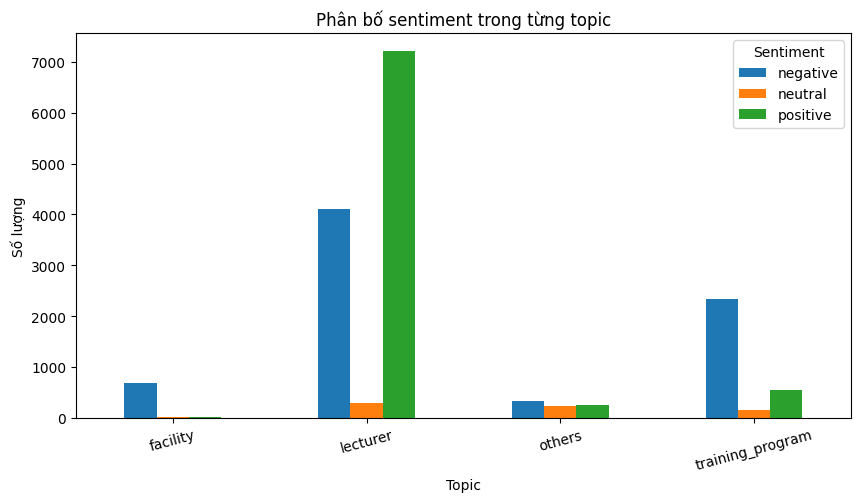

In [45]:
cross_tab = pd.crosstab(df["topic_label"], df["sentiment_label"])
display(cross_tab)


cross_tab.plot(kind="bar")
plt.title("Phân bố sentiment trong từng topic")
plt.xlabel("Topic")
plt.ylabel("Số lượng")
plt.xticks(rotation=15)
plt.legend(title="Sentiment")
plt.show()

làm sạch văn bản đơn giản

In [46]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

Hàm này dùng để:

chuyển chữ thường

bỏ dấu câu

xóa khoảng trắng dư

để phục vụ bước đếm từ xuất hiện nhiều.

Đếm từ xuất hiện nhiều nhất

In [48]:
all_words = " ".join(df["sentence"].apply(clean_text)).split()
word_freq = Counter(all_words)

top_words = pd.DataFrame(word_freq.most_common(20), columns=["word", "frequency"])
display(top_words)

,word,frequency
0,viên,6700
1,giảng,5239
2,dạy,4523
3,thầy,4409
4,sinh,4278
5,học,4114
6,bài,3309
7,tình,3211
8,không,3096
9,và,2904


In [49]:
for label in df["sentiment_label"].unique():
    print(f"\n===== {label.upper()} =====")
    display(df[df["sentiment_label"] == label][["sentence", "topic_label"]].head(5))


===== POSITIVE =====


,sentence,topic_label
0,slide giáo trình đầy đủ .,training_program
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",lecturer
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",lecturer
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",lecturer
10,thầy rất tận tình và đi dạy rất đúng giờ .,lecturer



===== NEGATIVE =====


,sentence,topic_label
2,đi học đầy đủ full điểm chuyên cần .,training_program
3,chưa áp dụng công nghệ thông tin và các thiết ...,lecturer
7,"thời lượng học quá dài , không đảm bảo tiếp th...",training_program
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",training_program
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,training_program



===== NEUTRAL =====


,sentence,topic_label
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",others
12,đang dạy thầy wzjwz208 đi qua nước ngoài giữa ...,lecturer
55,tạo ra sự cạnh tranh trong mỗi buổi thực hành .,lecturer
70,ôn tập đúng theo thầy nhưng không biết cuối kỳ...,training_program
116,bài tập trên lớp .,training_program


Cell này cho xem ví dụ thực tế của từng nhãn cảm xúc để hiểu dữ liệu rõ hơn.

In [50]:
for label in df["topic_label"].unique():
    print(f"\n===== {label.upper()} =====")
    display(df[df["topic_label"] == label][["sentence", "sentiment_label"]].head(5))


===== TRAINING_PROGRAM =====


,sentence,sentiment_label
0,slide giáo trình đầy đủ .,positive
2,đi học đầy đủ full điểm chuyên cần .,negative
7,"thời lượng học quá dài , không đảm bảo tiếp th...",negative
8,"nội dung môn học có phần thiếu trọng tâm , hầu...",negative
9,cần nói rõ hơn bằng cách trình bày lên bảng th...,negative



===== LECTURER =====


,sentence,sentiment_label
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",positive
3,chưa áp dụng công nghệ thông tin và các thiết ...,negative
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",positive
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",positive
10,thầy rất tận tình và đi dạy rất đúng giờ .,positive



===== OTHERS =====


,sentence,sentiment_label
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",neutral
11,dễ bị áp lực .,negative
15,hài lòng về tất cả .,positive
36,"chúc các thầy cô , anh chị làm việc vui vẻ !",positive
102,cần có sự tương tác giữa giảng viên và sinh vi...,negative



===== FACILITY =====


,sentence,sentiment_label
57,"cần nâng cấp hệ thống wifi , vì khi vào phòng ...",negative
75,"cần có một phòng máy tốt hơn , hiện đại hơn .",negative
93,cải thiện lại cơ sở vật chất máy chiếu trong p...,negative
128,mong ban thiết bị sớm khắc phục ạ !,negative
143,theo em thì nên thi phòng máy nào có visual 20...,negative
